In [8]:
import polars as pl

DATASET = 'gex_pre'

# gex = pl.read_csv(f'../dataset/created/gex/{DATASET}.csv')
# gex

gex = pl.read_csv(f'../dataset/original/gene_expressions.csv')

In [9]:
# gex_hugo = gex.filter(pl.col('patientID') == 'HL_Shi-43')
# gex_hugo

In [10]:
# # For each cohort (source), count how many KEGG melanoma genes are measured (non-null)
# with open('../dataset/kegg.txt') as f:
#     kegg_genes = set(g.strip() for g in f.read().split(',') if g.strip())

# kegg_in_dataset = (
#     gex.filter(pl.col('HGNC').is_in(kegg_genes))
#     .group_by('source')
#     .agg(pl.col('HGNC').n_unique().alias('n_kegg_genes_measured'))
#     .sort('n_kegg_genes_measured', descending=True)
#     .with_columns(pl.lit(len(kegg_genes)).alias('total_kegg_genes'))
# )

# print(f"Total KEGG genes: {len(kegg_genes)}")
# kegg_in_dataset

In [11]:
gex_sel = gex.filter(pl.col('source') == 'doi:10.1016/j.cell.2015.07.061')
gex_sel


id,creation_datetime,patientID,sample_id,HGNC,GeneID,description,value,temporality,source
i64,str,str,str,str,str,str,f64,str,str
7529600,"""2025-04-23 23:58:33.007122""","""HL_Shi-15""","""Pt1-DP1""","""A1BG""",null,null,9.152945,"""progression""","""doi:10.1016/j.cell.2015.07.061"""
7529601,"""2025-04-23 23:58:33.007142""","""HL_Shi-15""","""Pt1-DP1""","""A1BG-AS1""",null,null,2.13856,"""progression""","""doi:10.1016/j.cell.2015.07.061"""
7529602,"""2025-04-23 23:58:33.007157""","""HL_Shi-15""","""Pt1-DP1""","""A1CF""",null,null,0.0175659,"""progression""","""doi:10.1016/j.cell.2015.07.061"""
7529603,"""2025-04-23 23:58:33.007169""","""HL_Shi-15""","""Pt1-DP1""","""A2M""",null,null,45.64635,"""progression""","""doi:10.1016/j.cell.2015.07.061"""
7529604,"""2025-04-23 23:58:33.007181""","""HL_Shi-15""","""Pt1-DP1""","""A2M-AS1""",null,null,1.451535,"""progression""","""doi:10.1016/j.cell.2015.07.061"""
…,…,…,…,…,…,…,…,…,…
8641387,"""2025-04-24 00:42:16.629746""","""HL_Shi-40""","""Pt21-DP2""","""ZYG11A""",null,null,0.019542,"""progression""","""doi:10.1016/j.cell.2015.07.061"""
8641388,"""2025-04-24 00:42:16.629757""","""HL_Shi-40""","""Pt21-DP2""","""ZYG11B""",null,null,4.04421,"""progression""","""doi:10.1016/j.cell.2015.07.061"""
8641389,"""2025-04-24 00:42:16.629768""","""HL_Shi-40""","""Pt21-DP2""","""ZYX""",null,null,85.7967,"""progression""","""doi:10.1016/j.cell.2015.07.061"""


In [15]:
for col in gex_sel.to_pandas():
    print(gex_sel[col].unique())

shape: (1_111_792,)
Series: 'id' [i64]
[
	7529600
	7529601
	7529602
	7529603
	7529604
	…
	8641387
	8641388
	8641389
	8641390
	8641391
]
shape: (1_111_792,)
Series: 'creation_datetime' [str]
[
	"2025-04-24 00:26:14.541901"
	"2025-04-23 23:59:18.514424"
	"2025-04-24 00:41:59.999211"
	"2025-04-24 00:02:37.027280"
	"2025-04-24 00:08:06.793528"
	…
	"2025-04-24 00:26:13.671446"
	"2025-04-24 00:38:57.309145"
	"2025-04-24 00:24:03.516895"
	"2025-04-24 00:08:06.747288"
	"2025-04-24 00:42:02.749285"
]
shape: (13,)
Series: 'patientID' [str]
[
	"HL_Shi-40"
	"HL_Shi-35"
	"HL_Shi-26"
	"HL_Shi-44"
	"HL_Shi-43"
	…
	"HL_Shi-37"
	"HL_Shi-22"
	"HL_Shi-14"
	"HL_Shi-9"
	"HL_Shi-24"
]
shape: (44,)
Series: 'sample_id' [str]
[
	"Pt1-baseline"
	"Pt10-baseline"
	"Pt17-DP1"
	"Pt3-DP2"
	"Pt21-DD-DP1"
	…
	"Pt15-baseline"
	"Pt2-DP1"
	"Pt2-baseline"
	"Pt10-DP1"
	"Pt10-DP7"
]
shape: (25_268,)
Series: 'HGNC' [str]
[
	"LOC102724890"
	"DENND6A"
	"ZNF362"
	"MIR20B"
	"LOC643802"
	…
	"XPO7"
	"MIR6777"
	"OR2S2"
	"SEMG1"
	"A

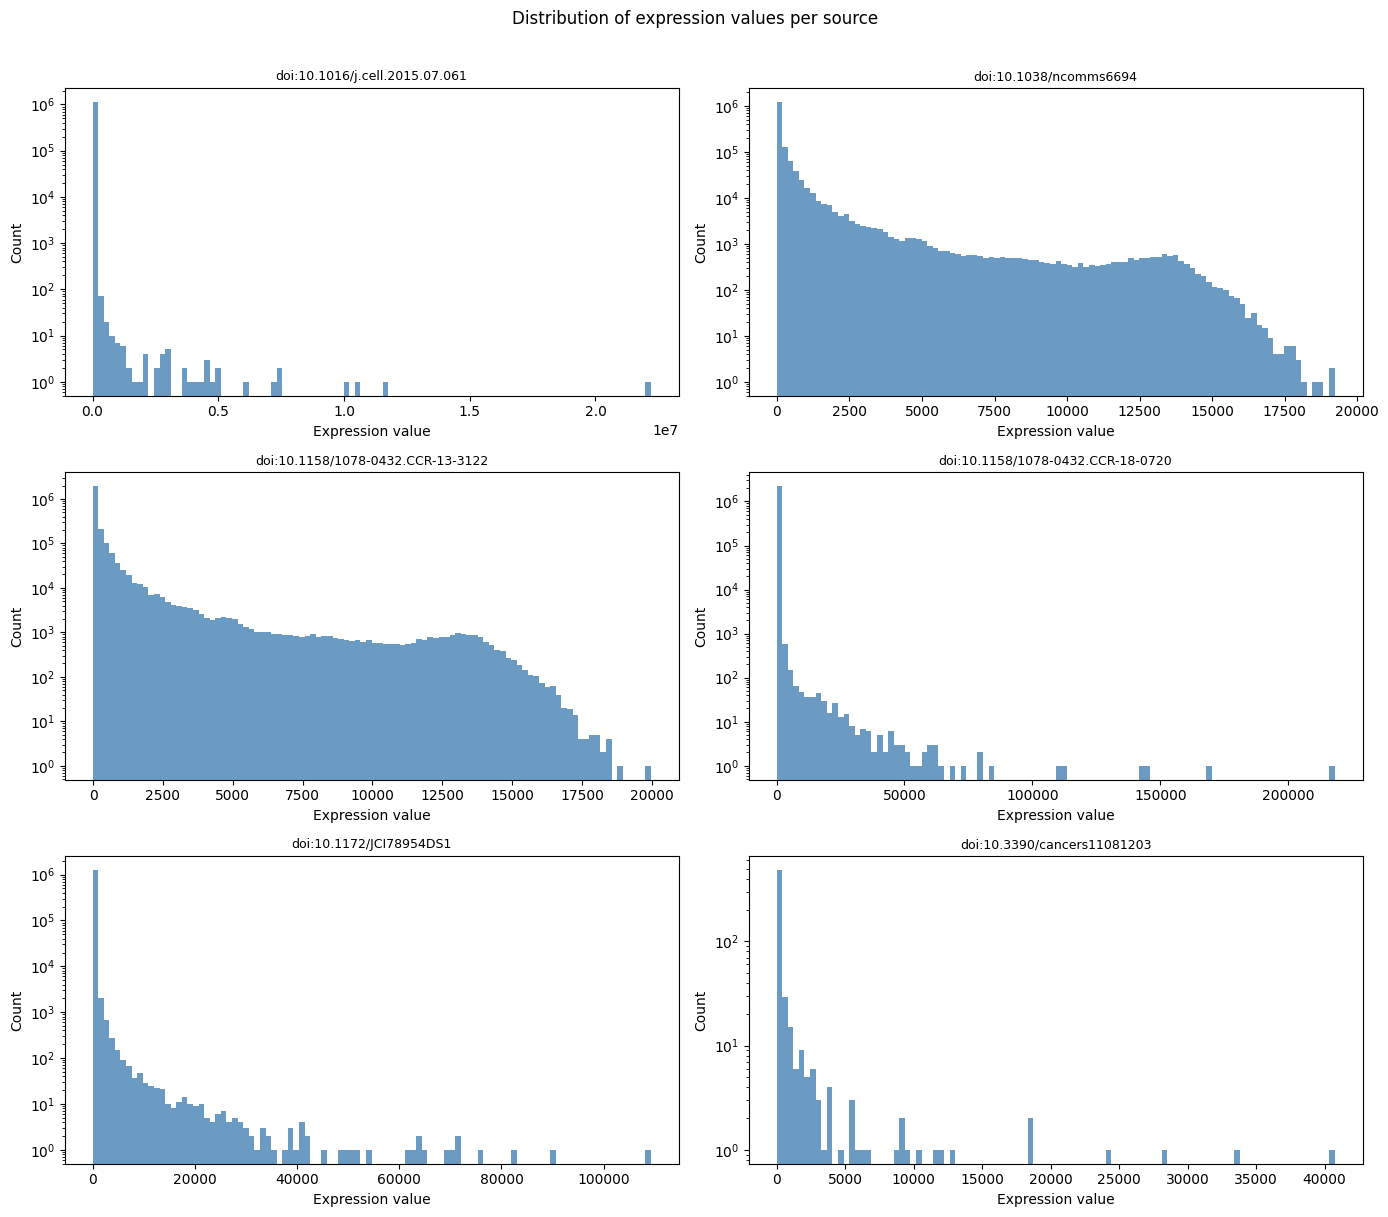

In [12]:
import matplotlib.pyplot as plt

sources = gex['source'].unique().to_list()
n = len(sources)
ncols = 2
nrows = (n + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()

for i, source in enumerate(sorted(sources)):
    vals = gex.filter(pl.col('source') == source)['value'].to_numpy()
    axes[i].hist(vals, bins=100, log=True, color='steelblue', edgecolor='none', alpha=0.8)
    axes[i].set_title(source, fontsize=9)
    axes[i].set_xlabel('Expression value')
    axes[i].set_ylabel('Count')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of expression values per source', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


In [13]:
import matplotlib.pyplot as plt
import numpy as np

hgnc_col = next((c for c in gex.columns if 'hgnc' in c.lower() or 'gene' in c.lower()), None)

stats = gex.group_by(["source", "Method"]).agg([
    pl.col("patientID").n_unique().alias("unique_patients"),
    pl.col("sample_id").n_unique().alias("unique_samples"),
    pl.col(hgnc_col).n_unique().alias("unique_genes"),
]).to_pandas()

method_colors = {"RNA-seq": "#4C72B0", "micro-array": "#DD8452", "qPCR": "#55A868"}
method_order = ["RNA sequencing", "micro-array", "qPCR"]

# Preserve original source order, grouped by method
rna_sources = stats[stats["Method"] == "RNA-seq"].sort_values("source")["source"].tolist()
micro_array_sources = stats[stats["Method"] == "micro-array"].sort_values("source")["source"].tolist()
qpcr_sources = stats[stats["Method"] == "qPCR"].sort_values("source")["source"].tolist()
ordered_sources = rna_sources + micro_array_sources + qpcr_sources

df = stats.set_index("source").loc[ordered_sources].reset_index()

metrics = [
    ("unique_patients", "Unique PatientIDs"),
    ("unique_samples",  "Unique SampleIDs"),
    ("unique_genes",    f"Unique {hgnc_col}"),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (col, title) in zip(axes, metrics):
    x = np.arange(len(df))
    colors = [method_colors[m] for m in df["Method"]]
    bars = ax.bar(x, df[col], color=colors)

    ax.set_title(title)
    ax.set_xlabel("Source")
    ax.set_ylabel("Count")
    ax.set_xticks(x)
    ax.set_xticklabels(df["source"], rotation=30, ha="right", fontsize=9)

    for bar, h in zip(bars, df[col]):
        ax.annotate(f"{h:,}", xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", va="bottom", fontsize=7)

    # Divider between method groups

handles = [plt.Rectangle((0,0),1,1, color=c, label=m) for m, c in method_colors.items()]
fig.legend(handles=handles, title="Method", loc="upper right", bbox_to_anchor=(1.01, 1))

plt.suptitle("Unique Counts per Source by Method", fontsize=13)
plt.tight_layout()
plt.show()


ColumnNotFoundError: unable to find column "Method"; valid columns: ["id", "creation_datetime", "patientID", "sample_id", "HGNC", "GeneID", "description", "value", "temporality", "source"]

Resolved plan until failure:

	---> FAILED HERE RESOLVING 'group_by' <---
DF ["id", "creation_datetime", "patientID", "sample_id", ...]; PROJECT */10 COLUMNS

This error occurred with the following context stack:
	[1] 'group_by'
